In [1]:
import json
import os
import random

import h5py
import numpy as np

import time
%matplotlib inline
import matplotlib.pyplot as plt

import robosuite
import imageio
from pprint import pprint   
from lxml import etree
from utils import update_xml, update_state

In [2]:
demo_path = "../robosuite/models/assets/demonstrations/1688900181_543158"
hdf5_path = os.path.join(demo_path, "demo.hdf5")
f = h5py.File(hdf5_path, "r")
env_name = f["data"].attrs["env"]
env_info = json.loads(f["data"].attrs["env_info"])
# env_info['camera_names'] = ['frontview', 'birdview', 'agentview', 'robot0_eye_in_hand']
env_info["camera_names"] = "frontview"
env_info["has_renderer"] = False
env_info["use_camera_obs"] = True
env_info["ignore_done"] = True
env_info["has_offscreen_renderer"] = True
env_info["camera_heights"] = 1024
env_info["camera_widths"] = 1024

In [3]:
env = robosuite.make(**env_info)

# list of all demonstrations episodes
demos = list(f["data"].keys())

# print("Playing back random episode... (press ESC to quit)")

i = 2
ep = demos[i]
# ep = "demo_10"
# os.path.exists(ep) or os.makedirs(ep)
env.reset()

# read the model xml, using the metadata stored in the attribute for this episode
model_xml = f["data/{}".format(ep)].attrs["model_file"]

env.reset()
xml = env.edit_model_xml(model_xml)
env.reset_from_xml_string(xml)
env.sim.reset()

states = f["data/{}/states".format(ep)][()]

# load the actions and play them back open-loop
actions = np.array(f["data/{}/actions".format(ep)][()])

# find obj_to_use
env.sim.set_state_from_flattened(states[-2])
env.step(actions[-1])
obj_id = np.where(env.objects_in_bins==1)[0][0]
obj_to_use = env.objects[obj_id]

env.sim.set_state_from_flattened(states[0])
env.sim.forward()

num_actions = actions.shape[0]
keyframes = []
keyframe_infos = []

# obj_id = env.object_to_id[env.obj_to_use.lower()]
# obj_id = env.object_to_id["bottle"]
# obj_to_use = env.objects[obj_id]

contacts = env.get_contacts(obj_to_use)
prev_con = contacts
max_len = len(contacts)

for j, action in enumerate(actions):
    obs, reward, done, info = env.step(action)

    contacts = env.get_contacts(obj_to_use)
    # print(env.sim.data.ncon)
    # if env.sim.data.ncon != prev_con:
    if contacts != prev_con:
        # keyframes.append(obs["frontview_image"][::-1, :, :])
        if (
            len(keyframe_infos) == 0
            or j - keyframe_infos[-1]["id"] > 20
            or (len(contacts) > max_len and np.all(['gripper' not in str(c) for c in contacts]))
            or "7" in prev_con - contacts
            or "21" in contacts - prev_con
        ):
            """
            Check if contacts changes every 10 steps, or
            if within 20 steps, the number of contacts increases or the can leaves the first table (7)
            or the can reach the second table (21)
            """
            keyframes.append(obs["frontview_image"][::-1, :, :])
            keyframe_infos.append(
                {
                    "id": j,
                    "previous_contact_geom_ids": sorted(prev_con, key=lambda x: str(x)),
                    "current_contact_geom_ids": sorted(contacts, key=lambda x: str(x)),
                }
            )
            # contact_list = [(x.geom1, x.geom2) for x in env.sim.data.contact]
            print(j, prev_con, contacts)
            max_len = max(max_len, len(contacts))

    # if contacts != prev_con:
    #     if contacts != set() and \
    #         not np.all([c == 7 or c == 21 or ('gripper' in env.sim.model.geom_id2name(c)) for c in contacts]):
    #         print(j, prev_con, contacts)
    #         keyframes.append(obs["frontview_image"][::-1, :, :])
    #         keyframe_ids.append(j)

    prev_con = contacts

    if j < num_actions - 1:
        # ensure that the actions deterministically lead to the same recorded states
        state_playback = env.sim.get_state().flatten()
        obj_id, state_data = update_state(state_playback.copy(), states[j + 1])
        if not np.all(np.equal(state_data, state_playback)):
            err = np.linalg.norm(state_data - state_playback)
            if err > 2:
                print("State mismatch in demo {} at step {}! Error: {}".format(ep, j, err))
                break

292 {7} {'gripper0_hand_collision', 7}
315 {'gripper0_finger2_collision', 'gripper0_finger2_pad_collision', 7} {'gripper0_finger2_collision', 'gripper0_finger1_pad_collision', 'gripper0_finger2_pad_collision', 7}
342 {'gripper0_finger2_collision', 'gripper0_finger1_pad_collision', 'gripper0_finger2_pad_collision'} {'gripper0_finger1_collision', 'gripper0_finger2_collision', 'gripper0_finger1_pad_collision', 'gripper0_finger2_pad_collision'}
467 {'gripper0_finger1_collision', 'gripper0_finger2_collision', 'gripper0_finger1_pad_collision', 'gripper0_finger2_pad_collision'} {'gripper0_finger1_collision', 'gripper0_finger1_pad_collision', 'gripper0_finger2_pad_collision', 'gripper0_finger2_collision', 'Cereal_g0'}
488 {'gripper0_finger1_collision', 'gripper0_finger1_pad_collision', 'gripper0_finger2_pad_collision', 'gripper0_finger2_collision', 'Cereal_g0'} {'gripper0_finger1_collision', 'gripper0_finger2_collision', 'gripper0_finger1_pad_collision', 'gripper0_finger2_pad_collision'}
593 {

In [4]:
len(keyframes)

6

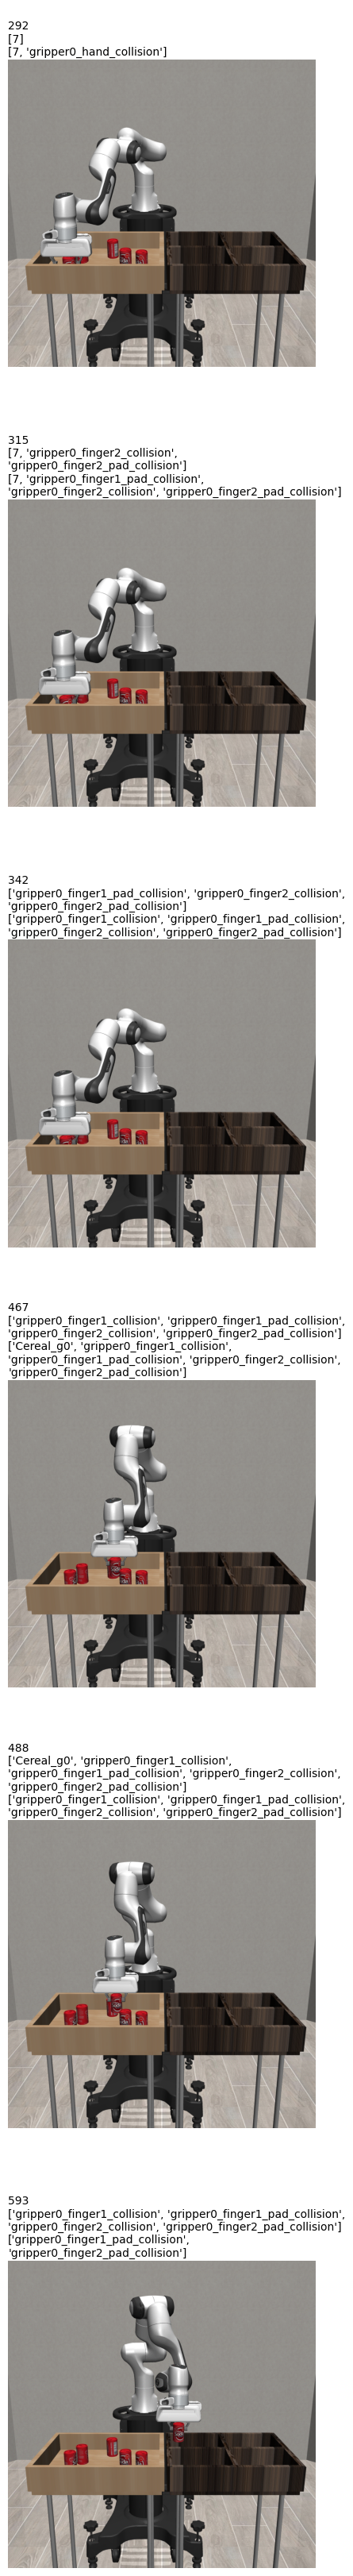

In [5]:
fig, axes = plt.subplots(len(keyframes), 1, figsize=(5, 7 * len(keyframes)))

for i, frame in enumerate(keyframes):
    axes[i].imshow(frame, aspect="equal")
    axes[i].set_axis_off()
    axes[i].text(0, -20, " ".join(['\n' + str(x) for x in list(keyframe_infos[i].values())]), wrap=True)
    # axes[i].set_title(str(list(keyframe_infos[i].values()))[1:-1], wrap=True)


plt.savefig(f"data/keyframe_plots/figure_{ep}.pdf", bbox_inches="tight")

In [6]:
env.obj_geom_id

{'Milk': [110],
 'Bread': [112],
 'Cereal': [114],
 'Can': [116],
 'Lemon': [118],
 'Bottle': [120]}

In [7]:
env.get_contacts(env.objects[env.object_to_id["bread"]])

{21}

In [8]:
for contact in env.sim.data.contact:
    print(contact.geom1, contact.geom2)

7 110
7 114
7 116
7 118
7 120
21 112


In [9]:
from robosuite.models.base import MujocoModel

isinstance(env.model, MujocoModel)

False

In [10]:
env.close()

In [11]:
env.objects_in_bins

array([0., 1., 0., 0., 0., 0.])